In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [19]:
images = [os.path.join('images',f) for f in os.listdir('images') if f.endswith(('.jpg'))]

In [20]:
len(images)

7390

In [21]:
imgs = [plt.imread(i) for i in images]

In [22]:
imgs = [i for i in imgs if i.shape[-1]==3]
shapes = ([np.array(img.shape) for img in (imgs)])

In [23]:
shapes = np.array(shapes)

In [24]:
shapes

array([[333, 500,   3],
       [375, 500,   3],
       [312, 500,   3],
       ...,
       [300, 220,   3],
       [333, 500,   3],
       [333, 500,   3]], shape=(7378, 3))

In [25]:
H,W,C = shapes.T

In [26]:
np.argmin(W)

np.int64(6409)

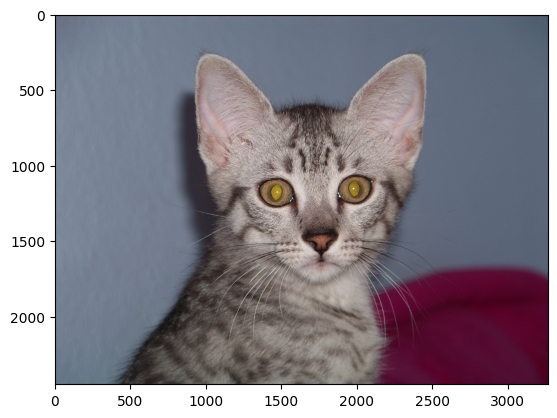

In [27]:
plt.imshow(imgs[5929])

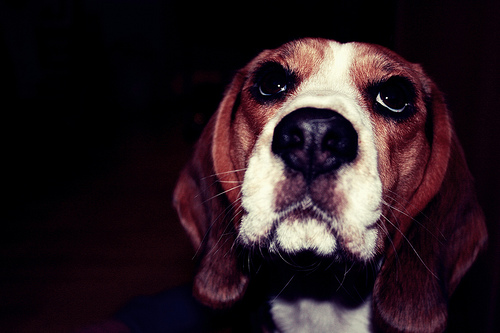

In [ ]:

d

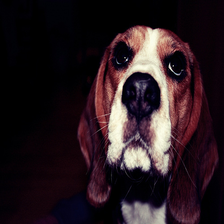

In [217]:
d.resize((224,224),resample=Image.LANCZOS)

In [170]:
from PIL.ImageOps import solarize,posterize,autocontrast,equalize

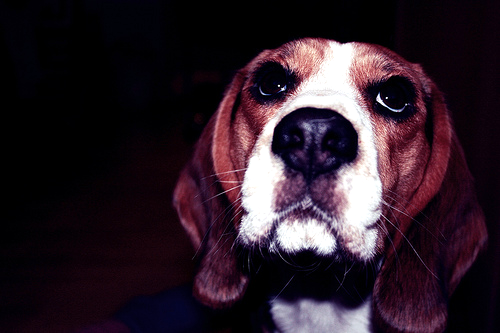

In [ ]:
import random
e = 


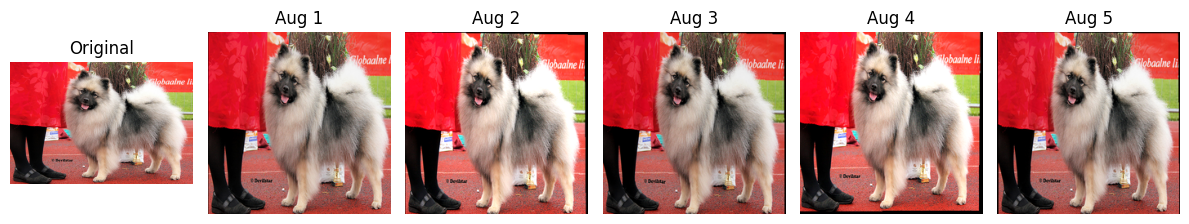

In [398]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL.ImageOps import autocontrast, posterize
from PIL.ImageTransform import AffineTransform

# pick random image
d = Image.fromarray(random.choice(imgs))

from PIL import ImageEnhance

def mild_color(img):
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.9, 1.1))
    return img

def slight_affine_coeffs(eps=0.02, translate=2):
    return (
        1 + random.uniform(-eps, eps),  # a
        random.uniform(-eps, eps),      # b
        random.uniform(-translate, translate),  # c
        random.uniform(-eps, eps),      # d
        1 + random.uniform(-eps, eps),  # e
        random.uniform(-translate, translate)   # f
    )

def augment(img):
    coeff = slight_affine_coeffs()
    t = AffineTransform(coeff)
    
    e = t.transform(img.size, img)
    e = e.resize((224, 224), Image.LANCZOS)
    
    e = mild_color(e)  # replace harsh ops
    
    return e

# generate 5 augmented images
augmented = [augment(d) for _ in range(5)]

# plot
plt.figure(figsize=(12, 4))

# original
plt.subplot(1, 6, 1)
plt.imshow(d)
plt.title("Original")
plt.axis("off")

# augmented
for i, img in enumerate(augmented):
    plt.subplot(1, 6, i + 2)
    plt.imshow(img)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

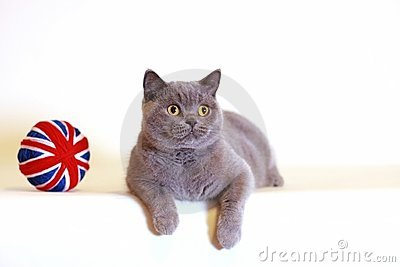

In [294]:
d

In [ ]:
import os
import xml.etree.ElementTree as ET

with open('annotations/trainval.txt') as f:
    content = f.read().split('\n')
# split the train val from the list above and the dataset takes this list as input 


# store (image_path, class_id, seg_path, species, breed_id)
data = []

for c in content:
    name,c_id,sp,brd = c.split(' ')
    class_id = int(c_id)
    species  = int(sp)
    breed_id = int(brd)

    img_path = os.path.join('images',name+'.jpg')
    seg_path = os.path.join('annotations/trimaps',name+'.png')

    data.append((img_path, class_id, seg_path, species, breed_id))

In [21]:
ET.parse("annotations/xmls/Abyssinian_1.xml")

In [33]:
not_exist = []
with open('annotations/test.txt') as f:
    content_test = f.read().split('\n')
for c in content_test:

    name,c_id,sp,brd = c.split(' ')

    if not os.path.exists(os.path.join('annotations/xmls', name+'.xml')):
        not_exist.append(name)


In [1]:
from data.pets_dataset import *


In [2]:
with open('data/annotations/trainval.txt') as f:
    contents = f.read().split('\n')

np.random.shuffle(contents)
split_idx = int(len(contents)*0.8)
train_data = contents[:split_idx]
val_data = contents[split_idx:]

In [3]:
train_dataset = OxfordIIITPetDataset_classify(train_data, transform=Image_transform)

In [4]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset,32,True)

In [5]:
import matplotlib.pyplot as plt

In [6]:
for img,class_id in train_dataloader:
    a = img
    break

In [8]:
a.shape

torch.Size([32, 3, 224, 224])

TypeError: transpose() received an invalid combination of arguments - got (list), but expected one of:
 * (int dim0, int dim1)
 * (name dim0, name dim1)
